# Exp-03 Camera Calibration

Camera Matrix:
 [[1.92e+03 0.00e+00 9.60e+02]
 [0.00e+00 1.92e+03 9.60e+02]
 [0.00e+00 0.00e+00 1.00e+00]]
Distortion Coefficients:
 [[0.]
 [0.]
 [0.]
 [0.]
 [0.]]


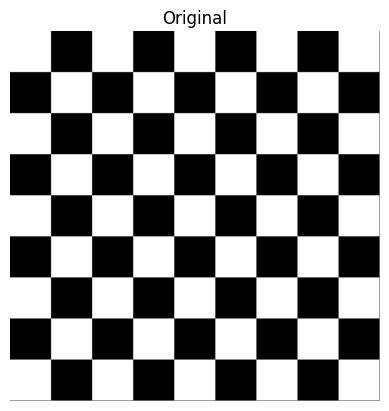

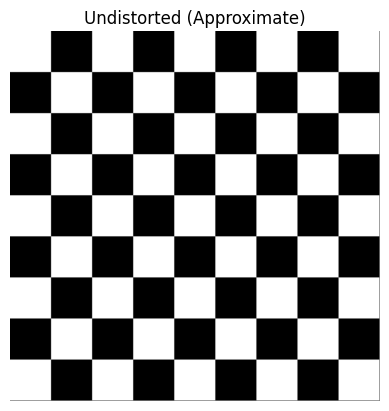

In [1]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('checkerboard-18x18.png')

# Check image
if img is None:
    print("Error loading image")
    exit()

# ---------------------------
# PREDEFINED CAMERA PARAMETERS
# ---------------------------
h, w = img.shape[:2]

# Approximate camera matrix
camera_matrix = np.array([
    [w, 0, w/2],
    [0, w, h/2],
    [0, 0, 1]
], dtype=np.float32)

# Assume no distortion (or very small)
dist_coeffs = np.zeros((5, 1))

print("Camera Matrix:\n", camera_matrix)
print("Distortion Coefficients:\n", dist_coeffs)

# ---------------------------
# UNDISTORT IMAGE
# ---------------------------
new_camera_matrix, roi = cv2.getOptimalNewCameraMatrix(
    camera_matrix, dist_coeffs, (w, h), 1, (w, h))

# Undistort
undistorted = cv2.undistort(img, camera_matrix, dist_coeffs, None, new_camera_matrix)

# Show result
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
undistorted_rgb = cv2.cvtColor(undistorted, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original")
plt.axis('off')
plt.show()

plt.imshow(undistorted_rgb)
plt.title("Undistorted (Approximate)")
plt.axis('off')
plt.show()